In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from classes import *

In [2]:
def separate_data(numbers, x_data, y_data):
    return x_data[np.concatenate([np.where(y_data == n)[0] for n in numbers])]

In [3]:
def load_data(path, split_data=1):
    data = []
    labels = []
    listpath = os.listdir(path)
    total = len(listpath)
    for subpath in listpath:
        complete_subpath = os.path.join(path, subpath)
        images = os.listdir(complete_subpath)
        total_images = len(images)
        labels.extend([int(subpath) for _ in range(int(total_images*split_data))])
        for idx, image_name in enumerate(images[:int(total_images*split_data)]):
            image_path = os.path.join(complete_subpath, image_name)
            image = cv.cvtColor(cv.imread(image_path), cv.COLOR_BGR2GRAY).reshape(-1)
            data.append(image)
            print(f'Images: [{idx+1}/{int(total_images*split_data)}]> in label [{subpath}/{total-1}]', end='\r')
    return np.array(data), np.array(labels)

In [ ]:
path = r'\Deep-Learning\datasets\fashion_mnist_images'
path_train = path + r'\train'
path_test = path + r'\test'

In [5]:
data_train, labels_train = load_data(path_train)
data_test, labels_test = load_data(path_test)

In [6]:
X_train = data_train / 255.0
X_test = data_test / 255.0

In [7]:
only_data = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
new_data = separate_data(only_data, X_train, labels_train)
np.random.shuffle(new_data)
X_train = new_data
new_data = separate_data(only_data, X_test, labels_test)

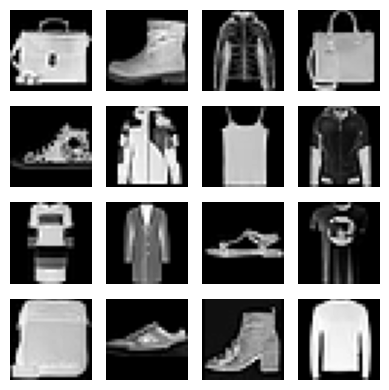

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(4, 4))
for ax in axes.flat:
    img = new_data[np.random.randint(0, new_data.shape[0])].reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
vae_model = VAE(
    n_inputs=new_data.shape[1],
    z_dim=128,
    neurons=64,
    n_outputs=new_data.shape[1],
    first_activation=LeakyReLU(),
    second_activation=ReLU(),
    last_activation=Sigmoid(),
    name='fashion_VAE'
)

In [10]:
vae_model.compile(
    loss=BinaryCrossEntropy(),
    optimizer=Adam(lr=0.001)
)

In [11]:
vae_model.train(new_data, epochs=20, batch_size=16, shuffle=True)

Epoch: [2/20] Loss: 0.4843 | KL_loss: 0.1340
Epoch: [4/20] Loss: 0.4667 | KL_loss: 0.1347
Epoch: [6/20] Loss: 0.4433 | KL_loss: 0.1188
Epoch: [8/20] Loss: 0.4338 | KL_loss: 0.1157
Epoch: [10/20] Loss: 0.4247 | KL_loss: 0.1120
Epoch: [12/20] Loss: 0.4215 | KL_loss: 0.1120
Epoch: [14/20] Loss: 0.4159 | KL_loss: 0.1081
Epoch: [16/20] Loss: 0.4191 | KL_loss: 0.1134
Epoch: [18/20] Loss: 0.4139 | KL_loss: 0.1091
Epoch: [20/20] Loss: 0.4115 | KL_loss: 0.1072


In [12]:
rand_image = X_test[np.random.randint(0, X_test.shape[0])]

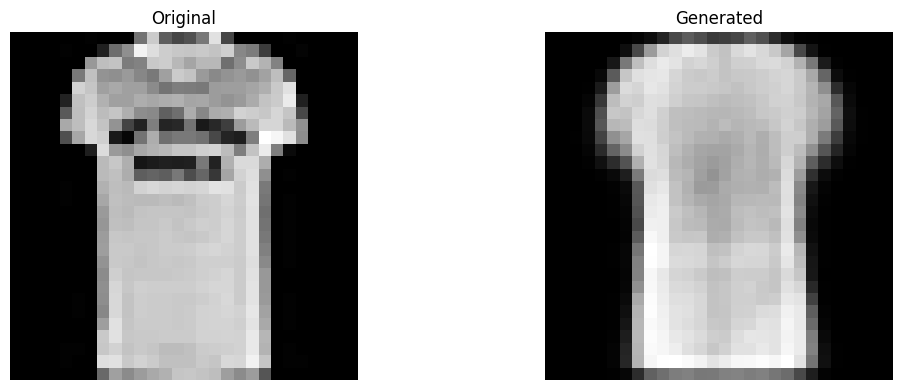

In [13]:
reconstruction= vae_model.forward(rand_image)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(rand_image.reshape(28, 28), cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(reconstruction.reshape(28, 28), cmap='gray')
axes[1].set_title("Generated")
axes[1].axis('off')

plt.tight_layout()
plt.show()